<div dir="rtl">

### بررسی تعداد آگهی‌های فروش و اجاره در ماه‌های مختلف

تعداد آگهی‌های فروش و اجاره در ماه‌های مختلف بررسی شود و مشخص شود آیا در بعضی ماه‌ها یا دوره‌های سال افزایش محسوسی در تعداد آگهی‌ها وجود دارد یا نه.

</div>

In [ ]:
import numpy as np
import pandas as pd 

In [13]:
import pandas as pd

df = pd.read_pickle("../data/Divar_cleaned.pkl")


In [16]:
print(df["cat2_slug"].value_counts(dropna=False))

cat2_slug
residential-sell        558708
residential-rent        276558
commercial-rent          76567
commercial-sell          38861
temporary-rent           29903
real-estate-services     19403
Name: count, dtype: int64


In [17]:
# ایجاد یک ستون متفاوت برای جهت دسته بندی به فروش و اجاره

df["listing_type"] = pd.NA

df.loc[
    df["cat2_slug"].isin(["residential-sell", "commercial-sell"]),
    "listing_type"
] = "sale"

df.loc[
    df["cat2_slug"].isin(["residential-rent", "commercial-rent", "temporary-rent"]),
    "listing_type"
] = "rent"

print(df["listing_type"].value_counts(dropna=False)) 


listing_type
sale    597569
rent    383028
<NA>     19403
Name: count, dtype: int64


In [18]:
# بررسی میزان فروش و اجاره در هر ماه و سال و ... 

monthly_counts = (
    df[df["listing_type"].notna()]
    .groupby(["created_year", "created_month", "listing_type"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

print(monthly_counts)


listing_type  created_year  created_month   rent   sale
0                     2020              2      0      1
1                     2020             12      1      0
2                     2021              2      0      1
3                     2021              5      0      1
4                     2021              6      0      1
5                     2021             11      0      1
6                     2021             12      1      1
7                     2022              1      0      1
8                     2022              2      1      1
9                     2022              3      1      0
10                    2022              4      3      2
11                    2022              5      4      2
12                    2022              6      3      1
13                    2022              7      3      1
14                    2022              8      3      6
15                    2022              9      5      1
16                    2022             10      2

<div dir="rtl">

### بررسی تعداد آگهی‌های فروش و اجاره در ماه‌های مختلف

برای بررسی روند زمانی آگهی‌ها، ابتدا آگهی‌ها بر اساس `cat2_slug` به دو گروه فروش و اجاره تقسیم شدند. سپس با استفاده از `created_year` و `created_month`، تعداد آگهی‌های هر گروه در ماه‌های مختلف محاسبه و مقایسه شد.

نتایج نشان داد بیشترین حجم آگهی‌های فروش و اجاره مربوط به سال **۲۰۲۴** بوده است.

- بیشترین تعداد آگهی‌های **اجاره** در ماه **۸ (آگوست)** مشاهده شد.
- بیشترین تعداد آگهی‌های **فروش** در ماه **۱۱ (نوامبر)** مشاهده شد.

در نتیجه، اوج فعالیت آگهی‌های اجاره و فروش در بازه‌های زمانی متفاوتی رخ داده است.

پایان شماره سوال شماره 3 آمارتوصیفی.


</div>

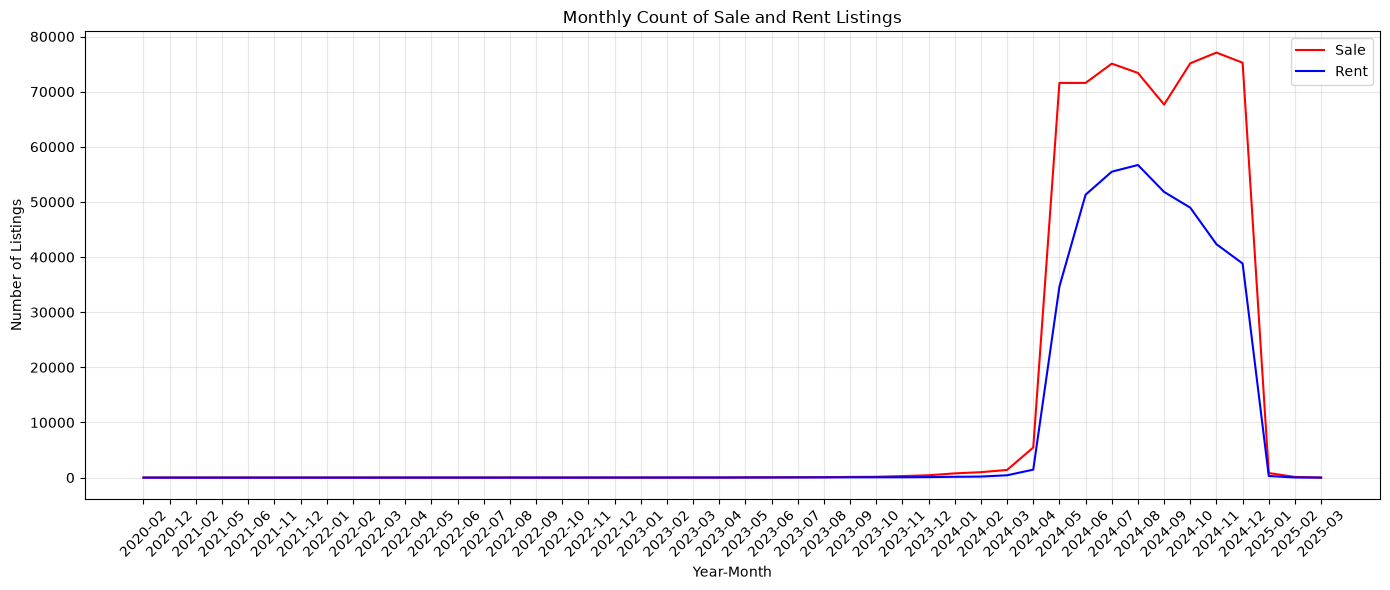

In [22]:
# رسم نمودار خطی برای فروش و اجاره

import matplotlib.pyplot as plt

# گرفتن کپی 
plot_df = monthly_counts.copy()

# Create a proper time label
plot_df["year_month"] = (
    plot_df["created_year"].astype(str)
    + "-"
    + plot_df["created_month"].astype(str).str.zfill(2)
)

# Sort by time
plot_df = plot_df.sort_values(["created_year", "created_month"])

# Plot
plt.figure(figsize=(14, 6))
plt.plot(plot_df["year_month"], plot_df["sale"], color="red", label="Sale")
plt.plot(plot_df["year_month"], plot_df["rent"], color="blue", label="Rent")

plt.title("Monthly Count of Sale and Rent Listings")
plt.xlabel("Year-Month")
plt.ylabel("Number of Listings")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

<div dir="rtl">

### بررسی توزیع قیمت فروش در دسته‌بندی‌های سطح سه

توزیع قیمت فروش (`price_value`) برای دسته‌بندی‌های مختلف سطح سه (`cat3_slug`) بررسی شود تا تفاوت الگوی قیمت بین انواع مختلف املاک مشخص شود.

در این بخش، قیمت‌های فروش در هر دسته به‌صورت جداگانه بررسی و مقایسه می‌شوند تا میزان پراکندگی، تمرکز قیمت‌ها و تفاوت میان دسته‌های مختلف مشخص شود.

</div>

In [23]:
print("Number of categories:", df["cat3_slug"].nunique(dropna=False))
print()

print(df["cat3_slug"].value_counts(dropna=False))

Number of categories: 17

cat3_slug
apartment-sell                        303385
apartment-rent                        211880
plot-old                              133570
house-villa-sell                      121753
house-villa-rent                       64678
shop-rent                              45993
shop-sell                              21855
office-rent                            21418
suite-apartment                        16465
presell                                15781
villa                                  12899
industry-agriculture-business-sell     11851
industry-agriculture-business-rent      9155
office-sell                             5155
partnership                             3622
workspace                                539
NaN                                        1
Name: count, dtype: int64


In [24]:
sale_df = df[
    df["cat2_slug"].isin([
        "residential-sell",
        "commercial-sell"
    ])
].copy()

In [25]:
print(sale_df["cat3_slug"].value_counts(dropna=False))

cat3_slug
apartment-sell                        303385
plot-old                              133570
house-villa-sell                      121753
shop-sell                              21855
industry-agriculture-business-sell     11851
office-sell                             5155
Name: count, dtype: int64


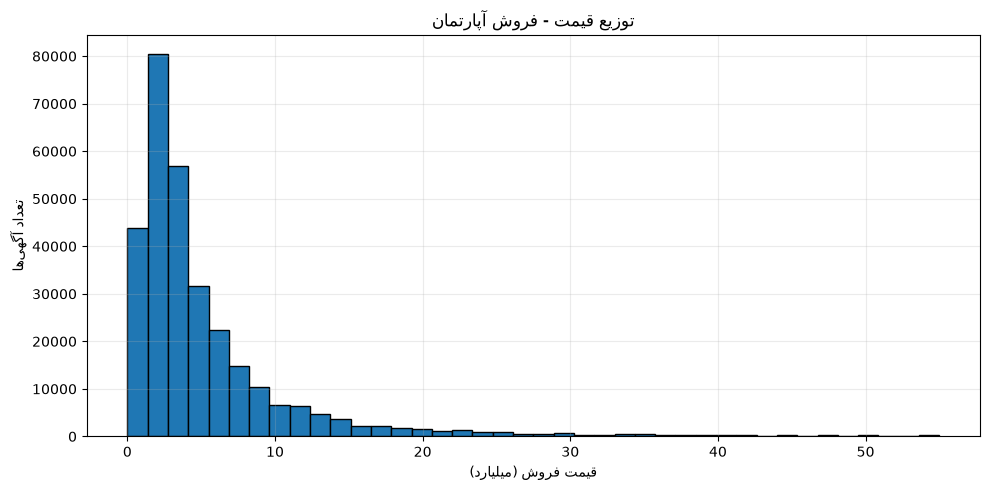

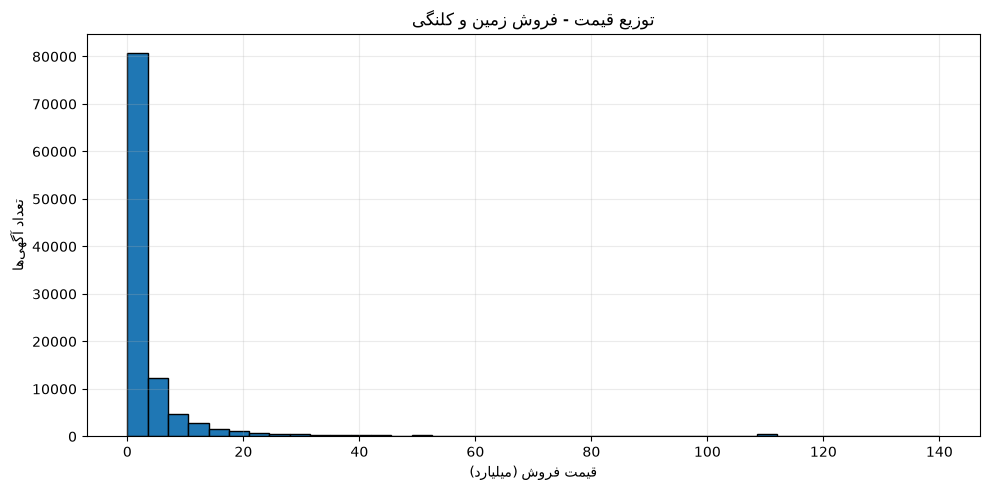

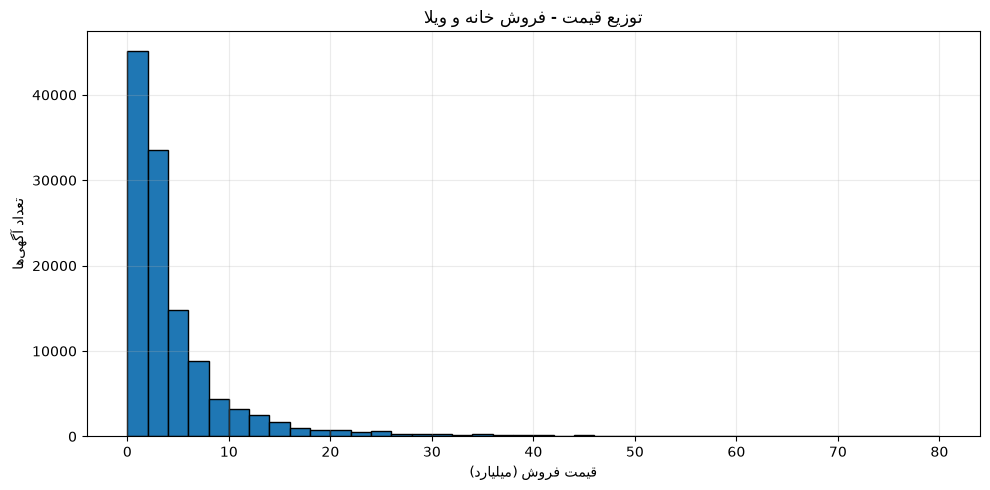

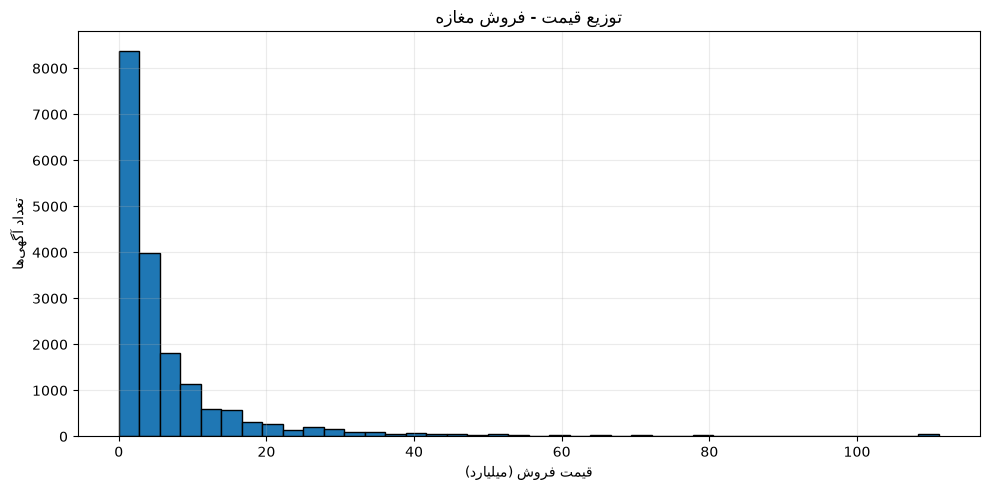

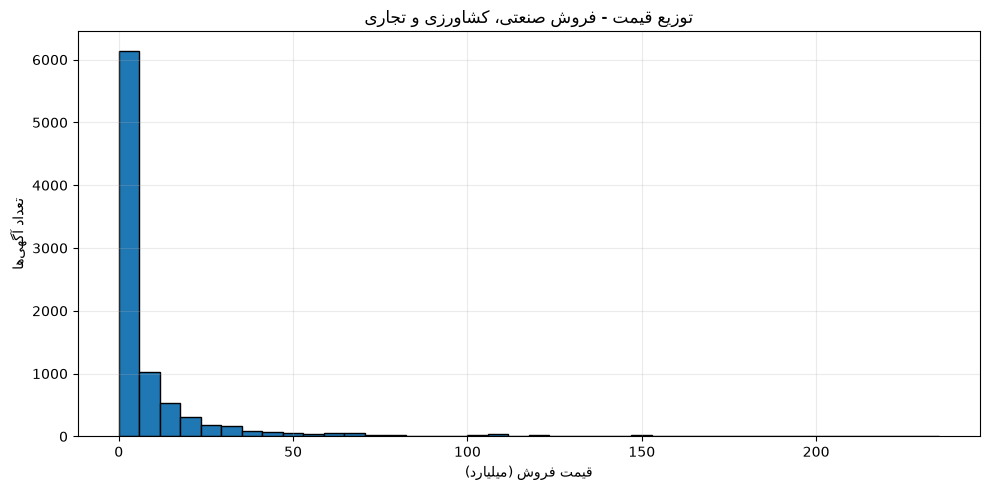

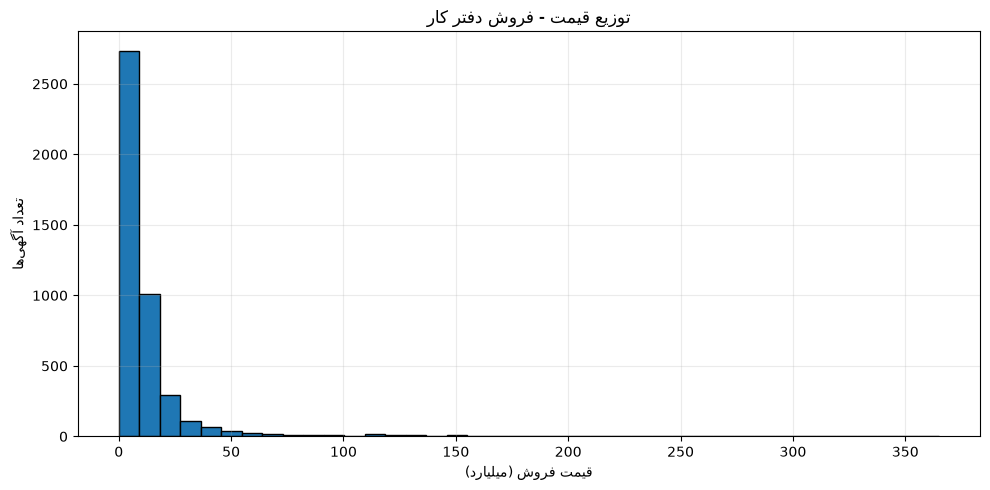

In [32]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

category_names = {
    "apartment-sell": "فروش آپارتمان",
    "plot-old": "فروش زمین و کلنگی",
    "house-villa-sell": "فروش خانه و ویلا",
    "shop-sell": "فروش مغازه",
    "industry-agriculture-business-sell": "فروش صنعتی، کشاورزی و تجاری",
    "office-sell": "فروش دفتر کار"
}

for category, title in category_names.items():

    prices = sale_df.loc[
        sale_df["cat3_slug"] == category,
        "price_value"
    ].dropna()

    x_max = prices.quantile(0.99)

    plt.figure(figsize=(10, 5))

    plt.hist(
        prices,
        bins=40,
        range=(0, x_max),
        edgecolor="black"
    )

    plt.gca().xaxis.set_major_formatter(
        FuncFormatter(lambda x, pos: f"{x / 1e9:.0f}")
    )

    plt.title(f"توزیع قیمت - {title}")
    plt.xlabel("قیمت فروش (میلیارد)")
    plt.ylabel("تعداد آگهی‌ها")

    plt.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

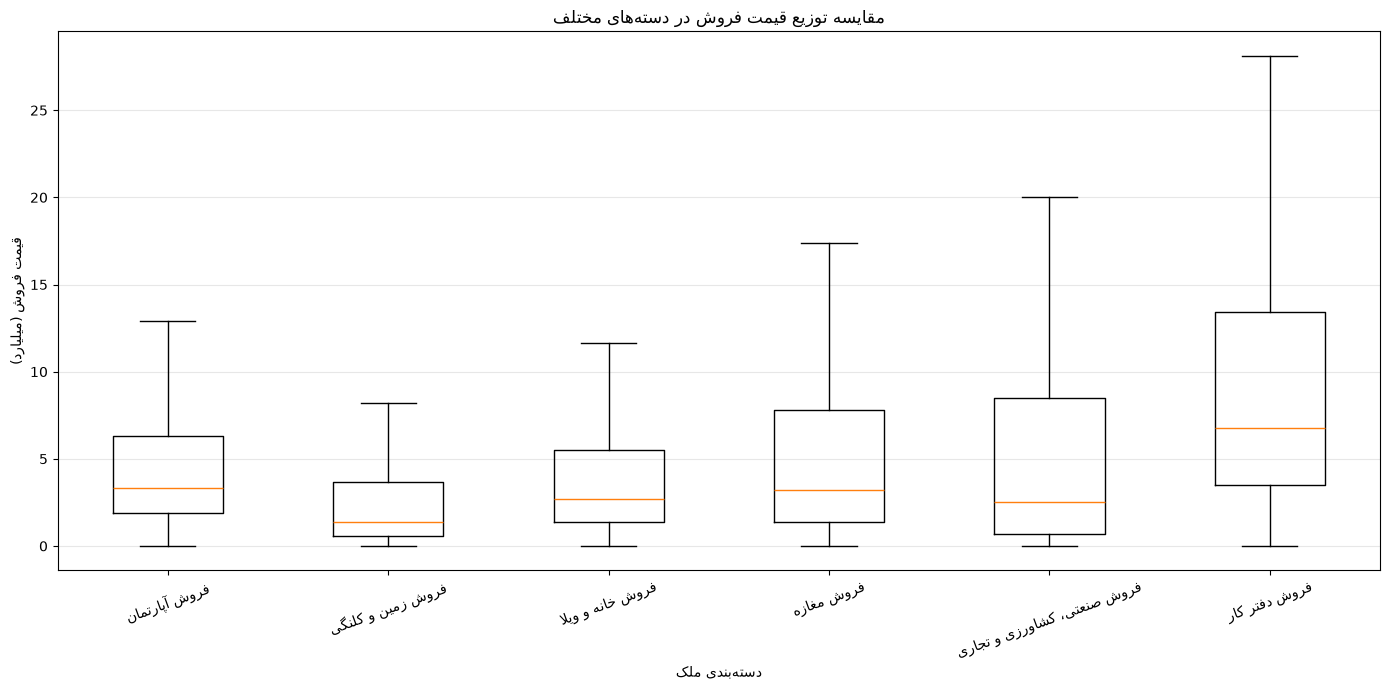

In [30]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

category_names = {
    "apartment-sell": "فروش آپارتمان",
    "plot-old": "فروش زمین و کلنگی",
    "house-villa-sell": "فروش خانه و ویلا",
    "shop-sell": "فروش مغازه",
    "industry-agriculture-business-sell": "فروش صنعتی، کشاورزی و تجاری",
    "office-sell": "فروش دفتر کار"
}

box_data = []
labels = []

for category, title in category_names.items():
    prices = sale_df.loc[
        sale_df["cat3_slug"] == category,
        "price_value"
    ].dropna()

    box_data.append(prices)
    labels.append(title)

plt.figure(figsize=(14, 7))

plt.boxplot(
    box_data,
    tick_labels=labels,
    showfliers=False
)

plt.gca().yaxis.set_major_formatter(
    FuncFormatter(lambda y, pos: f"{y / 1e9:.0f}")
)

plt.title("مقایسه توزیع قیمت فروش در دسته‌های مختلف")
plt.xlabel("دسته‌بندی ملک")
plt.ylabel("قیمت فروش (میلیارد)")

plt.xticks(rotation=20)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()